<a href="https://colab.research.google.com/github/Tejnaidu667/Daily_task/blob/main/ssp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
data=pd.read_csv("student_exam_scores.csv")
X = data.iloc[:, :-2].values
y_score = data['exam_score']

In [ ]:
print(X)

[['S001' 8.0 8.8 72.1]
 ['S002' 1.3 8.6 60.7]
 ['S003' 4.0 8.2 73.7]
 ['S004' 3.5 4.8 95.1]
 ['S005' 9.1 6.4 89.8]
 ['S006' 8.4 5.1 58.5]
 ['S007' 10.8 6.0 54.2]
 ['S008' 2.0 4.3 75.8]
 ['S009' 5.6 5.9 81.6]
 ['S010' 1.3 8.9 66.8]
 ['S011' 3.4 5.3 90.9]
 ['S012' 6.6 7.9 87.6]
 ['S013' 1.3 6.3 83.6]
 ['S014' 3.2 6.1 61.2]
 ['S015' 8.1 8.8 60.0]
 ['S016' 7.0 9.0 51.2]
 ['S017' 3.4 6.8 62.2]
 ['S018' 7.5 7.6 73.8]
 ['S019' 9.9 4.8 92.5]
 ['S020' 1.1 5.5 53.6]
 ['S021' 9.9 8.8 70.7]
 ['S022' 8.7 6.9 81.5]
 ['S023' 4.7 6.7 59.7]
 ['S024' 2.7 7.7 84.8]
 ['S025' 11.5 4.3 74.7]
 ['S026' 4.7 6.9 62.2]
 ['S027' 2.0 6.5 82.8]
 ['S028' 2.1 8.3 50.3]
 ['S029' 10.3 4.8 87.5]
 ['S030' 7.6 8.8 88.5]
 ['S031' 9.9 4.4 55.3]
 ['S032' 9.0 4.9 71.3]
 ['S033' 6.9 7.0 58.8]
 ['S034' 11.7 7.4 97.9]
 ['S035' 5.2 5.2 75.9]
 ['S036' 7.1 4.6 52.5]
 ['S037' 10.1 8.5 62.5]
 ['S038' 7.8 5.2 92.4]
 ['S039' 10.5 7.0 72.8]
 ['S040' 7.4 7.1 90.1]
 ['S041' 8.8 6.1 83.4]
 ['S042' 1.5 6.9 99.4]
 ['S043' 3.5 6.6 79.8]
 ['S0

In [ ]:
data

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [ ]:
data.head(10)

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
5,S006,8.4,5.1,58.5,75,35.7
6,S007,10.8,6.0,54.2,88,37.9
7,S008,2.0,4.3,75.8,55,18.3
8,S009,5.6,5.9,81.6,84,34.7
9,S010,1.3,8.9,66.8,70,24.7


In [ ]:
data.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [40]:
data.isnull().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [41]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [ ]:
print("Regression target (Exam_Score):")
print(y_score)

Regression target (Exam_Score):
0      30.2
1      25.0
2      35.8
3      34.0
4      40.3
       ... 
195    42.7
196    40.4
197    28.2
198    42.0
199    37.8
Name: exam_score, Length: 200, dtype: float64


In [37]:
from sklearn.impute import SimpleImputer  # Import tool used to fill missing values

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# Create an imputer that replaces NaN values with the mean of the column

imputer.fit(X[:, 1:3])
# Learn the mean values from columns 1 and 2 of X (Area_sqft and Bedrooms)

X[:, 1:3] = imputer.transform(X[:, 1:3])

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and classification target


# Split regression target (Price_Lakhs) with the same random_state
_, _, y_train_price, y_test_price = train_test_split(X, y_score, test_size=0.2, random_state=1)

In [42]:
data=data.drop("student_id",axis=1)

In [44]:
for col in data:
  print(data[col].value_counts())
  print("--------------------------------------------")

hours_studied
3.9     7
3.5     6
10.5    5
3.4     5
9.9     4
       ..
2.3     1
7.3     1
6.1     1
11.8    1
10.2    1
Name: count, Length: 96, dtype: int64
--------------------------------------------
sleep_hours
5.5    9
5.3    7
6.1    6
8.8    6
6.0    6
7.6    6
8.5    6
8.7    6
8.3    6
6.9    6
8.4    6
4.6    5
6.7    5
4.0    5
8.9    5
8.2    5
5.1    5
4.8    5
4.5    5
5.6    4
5.4    4
5.2    4
7.3    4
7.1    4
6.3    4
7.9    4
8.1    4
7.4    4
4.4    4
7.7    4
7.0    4
8.6    3
4.3    3
6.8    3
8.0    3
7.2    3
9.0    3
5.0    3
6.4    2
5.9    2
4.9    2
6.6    2
5.7    2
4.7    2
5.8    2
7.5    2
4.1    2
6.5    1
7.8    1
6.2    1
Name: count, dtype: int64
--------------------------------------------
attendance_percent
92.5    4
62.2    3
88.3    3
69.0    3
71.8    3
       ..
94.0    1
85.1    1
63.8    1
50.5    1
97.4    1
Name: count, Length: 167, dtype: int64
--------------------------------------------
previous_scores
58    9
84    7
70    7
54    7

In [45]:
#split data
x=data.drop("exam_score",axis=1)
y=data["exam_score"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#choose algorthim and create object
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

# training model
reg.fit(x_train,y_train)

#accuracy of model
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
y_pred=reg.predict(x_test)
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred)}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred)}")
print(f"r2_score:{r2_score(y_test,y_pred)}")

mean_squared_error:7.761782668623075
mean_absolute_error:2.310858235895833
r2_score:0.8537447137159516


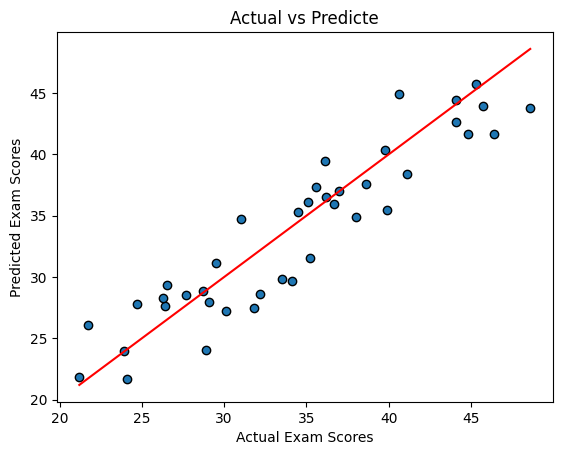

In [46]:
#scatter for draw relation between y_test and y_pred
plt.scatter(y_test,y_pred,edgecolors="black")
plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Actual vs Predicte')
#prefect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], ls="-", color="red")
plt.show()

In [47]:
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ── FUNCTION 1: For Regression Models ──────────────────────────────────────
# Metric used: R2 Score
# R2 Score tells how well the model explains the variation in the actual values.
# Score of 1.0 = perfect predictions. Score of 0.0 = model is no better than the mean.
def show_regression_metrics(y_true, y_pred, model_name="Model"):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"Regression Metrics — {model_name}")
    print(f"  R2 Score : {r2:.4f}   (closer to 1.0 = better)")
    print(f"  RMSE     : {rmse:.2f}")
    return r2, rmse



In [55]:
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8537447137159516
7.761782668623075


In [57]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

y_pred_regressor = regressor.predict(x_test)
r2_lr, rmse_lr = show_regression_metrics(y_test, y_pred_regressor, model_name="Linear Regressor")

Regression Metrics — Linear Regressor
  R2 Score : 0.8537   (closer to 1.0 = better)
  RMSE     : 2.79


(0.8537447137159516, np.float64(2.785997607433121))

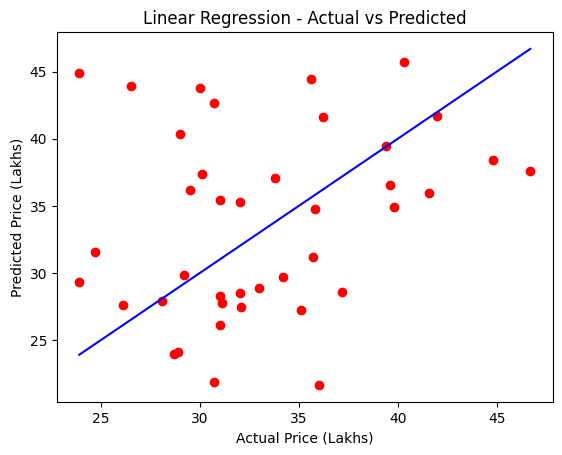

In [58]:
plt.scatter(y_test_price, y_pred, color='red')
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], color='blue')
plt.title('Linear Regression - Actual vs Predicted')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.show()

In [59]:
# ── SAVE MODEL ──
import pickle

# Save the trained Linear Regression model to a file
with open('linear_regression.pkl', 'wb') as f:
    pickle.dump(regressor, f)

print("Model saved as 'linear_regression.pkl'")
print()

print("To load the model later:")
print("  import pickle")
print("  model = pickle.load(open('linear_regression.pkl', 'rb'))")
print("  model.predict(X_test)")

Model saved as 'linear_regression.pkl'

To load the model later:
  import pickle
  model = pickle.load(open('linear_regression.pkl', 'rb'))
  model.predict(X_test)


In [63]:
# 📦 Import for this model
from sklearn .tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# ── TRAIN ──
# Regression: predict numeric house price
model_dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt_reg.fit(x_train, y_train)
print("Decision Tree trained (Regression )")

Decision Tree trained (Regression )


In [67]:
# ── PREDICT & METRICS ──
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Regression evaluation
y_pred_dt_reg = model_dt_reg.predict(x_test)
r2_dt, rmse_dt = show_regression_metrics(
    y_test, y_pred_dt_reg, "Decision Tree Regression"
)

print()

Regression Metrics — Decision Tree Regression
  R2 Score : 0.6737   (closer to 1.0 = better)
  RMSE     : 4.16



In [69]:
import pandas as pd

# Create a sample input matching the training features
sample_input = pd.DataFrame({
    'hours_studied': [8.0],
    'sleep_hours': [8.8],
    'attendance_percent': [72.1],
    'previous_scores': [45]
})

# Make a prediction using the trained Linear Regression model
predicted_score = regressor.predict(sample_input)

print(f"Predicted Exam Score: {predicted_score[0]:.2f}")

Predicted Exam Score: 34.06


In [71]:
# ── SAVE MODEL ──
import pickle

with open('decision_tree_regressor.pkl', 'wb') as f:
    pickle.dump(model_dt_reg, f)


print("✅ Saved: decision_tree_regressor.pkl")


✅ Saved: decision_tree_regressor.pkl


In [73]:
# ── ALL RESULTS TABLE ──
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Ensure models are available (assuming regressor and model_dt_reg are defined in previous cells)
# If not, you might need to re-run the training cells or redefine them here.

# Recalculate metrics for Linear Regression
y_pred_regressor = regressor.predict(x_test)
r2_lr, rmse_lr = r2_score(y_test, y_pred_regressor), np.sqrt(mean_squared_error(y_test, y_pred_regressor))

# Recalculate metrics for Decision Tree
y_pred_dt_reg = model_dt_reg.predict(x_test)
r2_dt, rmse_dt = r2_score(y_test, y_pred_dt_reg), np.sqrt(mean_squared_error(y_test, y_pred_dt_reg))

print("=" * 58)
print("📈  REGRESSION  —  Predict Exam Score (number)")
print("=" * 58)
print(f"  {'Model':<24} {'R² Score':>10}   {'RMSE':>10}")
print("  " + "─" * 50)

reg_scores = [
    ("Linear Regression",  r2_lr,  rmse_lr),
    ("Decision Tree",      r2_dt,  rmse_dt)
]
medals = ["🥇", "🥈"]
reg_sorted = sorted(reg_scores, key=lambda x: x[1], reverse=True)
for i, (name, r2, rmse) in enumerate(reg_sorted):
    print(f"  {medals[i]}  {name:<22} {r2:>10.4f}   {rmse:>10.2f}")

print()
# Removed CLASSIFICATION section as no classification models were trained.

📈  REGRESSION  —  Predict Exam Score (number)
  Model                      R² Score         RMSE
  ──────────────────────────────────────────────────
  🥇  Linear Regression          0.8537         2.79
  🥈  Decision Tree              0.6737         4.16

